<a href="https://colab.research.google.com/github/gabrielcord/recpad20252/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST

**Aluno:** Gabriel Cordeiro

**Disciplina:** Redes Neurais Artificiais

**Semestre:** 2026/1

## Enunciado

Procurar a base de dados original do MNIST e rodar uma rede neural com camadas convolucionais.

Não pode ser a que vem no Keras. Tem que baixar e fazer o preprocessamento.

## Solução

### Preparação do dataset

O endereço oficial do dataset MNIST (http://yann.lecun.com/exdb/mnist/) encontra-se vazio, portanto será usada como fonte alternativa a Common Visual Data Foundation (https://github.com/cvdfoundation/mnist).


> This page intends to provide a mirror site for downloading MNIST database hosted on http://yann.lecun.com/exdb/mnist/. Please visit the original site for more details of dataset.



#### Download dos arquivos

In [36]:
!mkdir -p mnist_data
!curl https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz | gunzip > mnist_data/train-images-idx3-ubyte
!curl https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz | gunzip > mnist_data/train-labels-idx1-ubyte
!curl https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz | gunzip > mnist_data/t10k-images-idx3-ubyte
!curl https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz | gunzip > mnist_data/t10k-labels-idx1-ubyte

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 9680k  100 9680k    0     0  5300k      0  0:00:01  0:00:01 --:--:-- 5298k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 28881  100 28881    0     0  38922      0 --:--:-- --:--:-- --:--:-- 38923
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1610k  100 1610k    0     0  1085k      0  0:00:01  0:00:01 --:--:-- 1085k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4542  100  4542    0     0   6216      0 --:--:-- --:--:-- --:--:--  6213


#### Carregamento dos dados

In [37]:
import torch
import numpy as np
import struct
import os

def load_mnist_data(images_path, labels_path):
  # Lê o cabeçalho do arquivo de imagens e converte os dados brutos em array
  with open(images_path, 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, 1, rows, cols)

  # Lê o cabeçalho do arquivo de rótulos e converte os dados brutos em array
  with open(labels_path, 'rb') as f:
    _, n = struct.unpack('>II', f.read(8))
    labels = np.frombuffer(f.read(), dtype=np.uint8)

  # Cria cópias dos arrays e converte para tensores normalizados
  images_tensor = torch.from_numpy(images.copy()).float() / 255.0
  labels_tensor = torch.from_numpy(labels.copy()).long()

  return images_tensor, labels_tensor

# Carregamento dos arquivos
train_images, train_labels = load_mnist_data('mnist_data/train-images-idx3-ubyte', 'mnist_data/train-labels-idx1-ubyte')
test_images, test_labels = load_mnist_data('mnist_data/t10k-images-idx3-ubyte', 'mnist_data/t10k-labels-idx1-ubyte')

In [38]:
from torch.utils.data import TensorDataset, DataLoader

# Criação dos Datasets e DataLoaders
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Shapes de treino: Imagens {train_images.shape}, Labels {train_labels.shape}")

Shapes de treino: Imagens torch.Size([60000, 1, 28, 28]), Labels torch.Size([60000])


### Definição da CNN

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
  def __init__(self, input_shape, num_classes):
    super().__init__()
    # Camadas convolucionais
    self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=3)
    self.pool1 = nn.MaxPool2d(2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
    self.pool2 = nn.MaxPool2d(2)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

    self.flatten = nn.Flatten()
    self.fc = nn.Linear(128 * 3 * 3, num_classes)

  def forward(self, x):
    x = self.pool1(F.relu(self.conv1(x)))
    x = self.pool2(F.relu(self.conv2(x)))
    x = F.relu(self.conv3(x))
    x = self.flatten(x)
    return self.fc(x)

  def fit(self, loader, optimizer, criterion, device, epochs):
    self.train()
    for epoch in range(epochs):
      for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = self(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
      print(f"Época {epoch+1} finalizada.")

  def predict(self, inputs, device):
    self.eval()
    with torch.no_grad():
      inputs = inputs.to(device)
      outputs = self(inputs)
      _, predicted = torch.max(outputs, 1)
    return predicted

### Treinamento do modelo

In [40]:
import torch.optim as optim

# Configuração do modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(input_shape=(1, 28, 28), num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Execução do treinamento
model.fit(train_loader, optimizer, criterion, device, epochs=7)

Época 1 finalizada.
Época 2 finalizada.
Época 3 finalizada.
Época 4 finalizada.
Época 5 finalizada.
Época 6 finalizada.
Época 7 finalizada.


### Avaliação do modelo

In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predição e avaliação no conjunto de teste
preds = model.predict(test_images, device)

labels_cpu = test_labels.cpu().numpy()
preds_cpu = preds.cpu().numpy()

print(f"Acurácia: {accuracy_score(labels_cpu, preds_cpu) * 100:.2f}%")

Acurácia: 99.20%


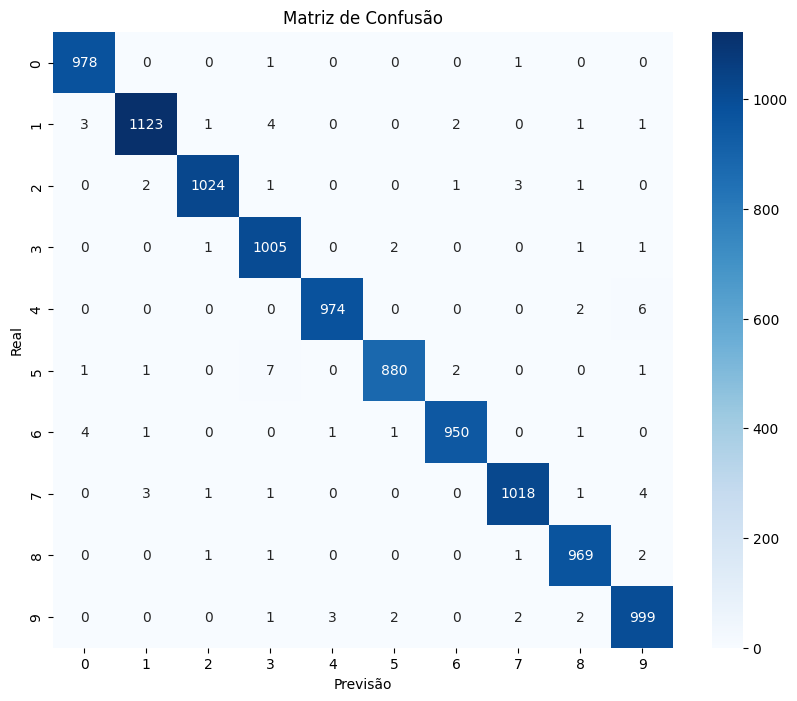

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_cpu, preds_cpu)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()